In [1]:
# ─────────────────────────────────────────────
# [C1] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
!pip install scikit-learn xgboost matplotlib seaborn -q
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

import sklearn, xgboost
print("준비 완료 ✓")
print(f"- scikit-learn {sklearn.__version__}")
print(f"- xgboost      {xgboost.__version__}")

준비 완료 ✓
- scikit-learn 1.9.0
- xgboost      3.2.0


In [2]:
# ─────────────────────────────────────────────
# [C2] ◀ Part 0 · ⚙️ 환경 설정과 실습 데이터 데이터 로드 — 분류(유방암) + 회귀(당뇨), 전부 sklearn 내장 (인터넷 불필요)
# ─────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split

# 메인 분류 데이터: 유방암 진단 (이진분류) — 🎬 오늘의 무대에서 소개한 공개 실습 데이터
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

print(f"분류 데이터(유방암): 학습 {Xc_tr.shape[0]} / 테스트 {Xc_te.shape[0]} | 피처 {Xc.shape[1]}개")
print(f"  클래스: {dict(zip(['악성(0)','양성(1)'], np.bincount(yc)))}")

분류 데이터(유방암): 학습 455 / 테스트 114 | 피처 30개
  클래스: {'악성(0)': np.int64(212), '양성(1)': np.int64(357)}


In [3]:
# ─────────────────────────────────────────────
# [C3] ◀ Part 1 · 🔍 자세히 알아보기 — 분할 기준(불순도와 정보획득) 지니 불순도를 직접 계산해 보기
# ─────────────────────────────────────────────
def gini(counts):
    counts = np.array(counts, dtype=float)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

print("순수(5:0):", round(gini([5, 0]), 3), "→ 완전 순수")
print("반반(5:5):", round(gini([5, 5]), 3), "→ 가장 불순")
print("치우침(8:2):", round(gini([8, 2]), 3))

# 분할 전후 정보획득 예시: 루트(5:5) → 왼쪽(5:0)/오른쪽(0:5)
before = gini([5, 5])
after = 0.5 * gini([5, 0]) + 0.5 * gini([0, 5])   # 가중 평균
print(f"\n정보획득 = {before:.3f} - {after:.3f} = {before-after:.3f}  (완벽 분할!)")

순수(5:0): 0.0 → 완전 순수
반반(5:5): 0.5 → 가장 불순
치우침(8:2): 0.32

정보획득 = 0.500 - 0.000 = 0.500  (완벽 분할!)


테스트 정확도 = 0.939


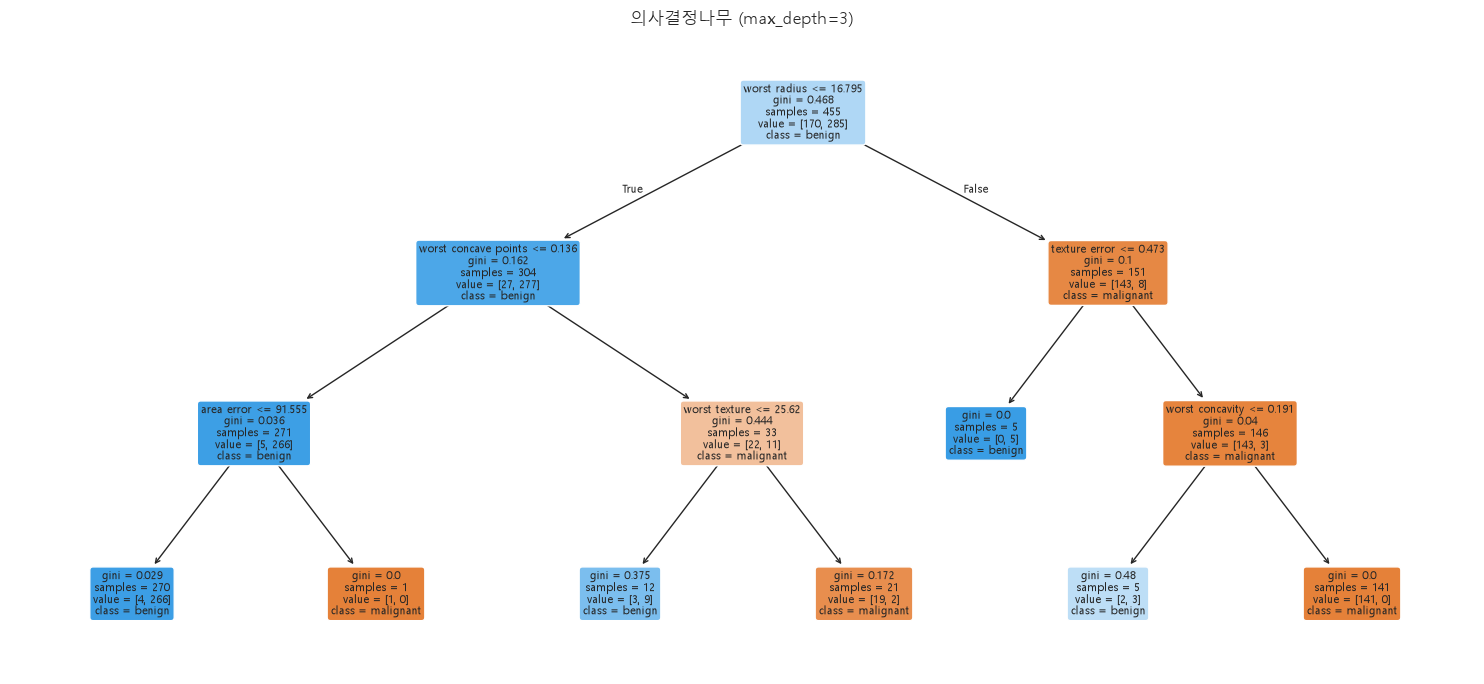

In [4]:
# [C4] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
gini_score = tree.fit(Xc_tr, yc_tr)
print(f"테스트 정확도 = {gini_score.score(Xc_te, yc_te):.3f}")

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree, feature_names=Xc.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title("의사결정나무 (max_depth=3)")
plt.tight_layout(); plt.show()

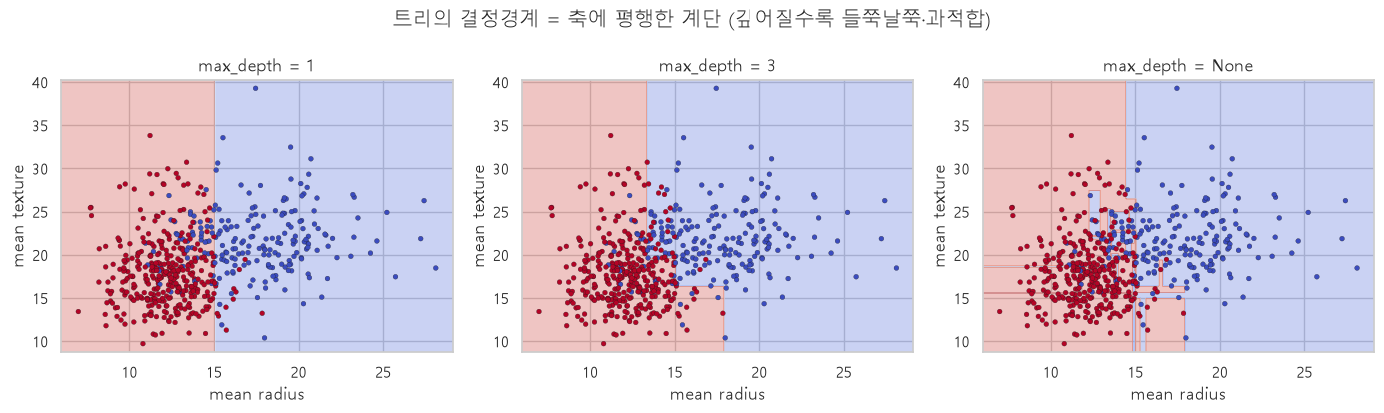

In [5]:
# ─────────────────────────────────────────────
# [C5] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기 단일 트리의 결정경계 (계단 모양) — 깊이별 비교
# ─────────────────────────────────────────────
feats = ["mean radius", "mean texture"]
X2 = Xc[feats].values
import numpy as np
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, d in zip(axes, [1, 3, None]):
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X2, yc)
    zz = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2[:,0], X2[:,1], c=yc, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(f"max_depth = {d}"); ax.set_xlabel(feats[0]); ax.set_ylabel(feats[1])
plt.suptitle("트리의 결정경계 = 축에 평행한 계단 (깊어질수록 들쭉날쭉·과적합)")
plt.tight_layout(); plt.show()

테스트 정확도 = 0.947
테스트 정확도 = 0.939


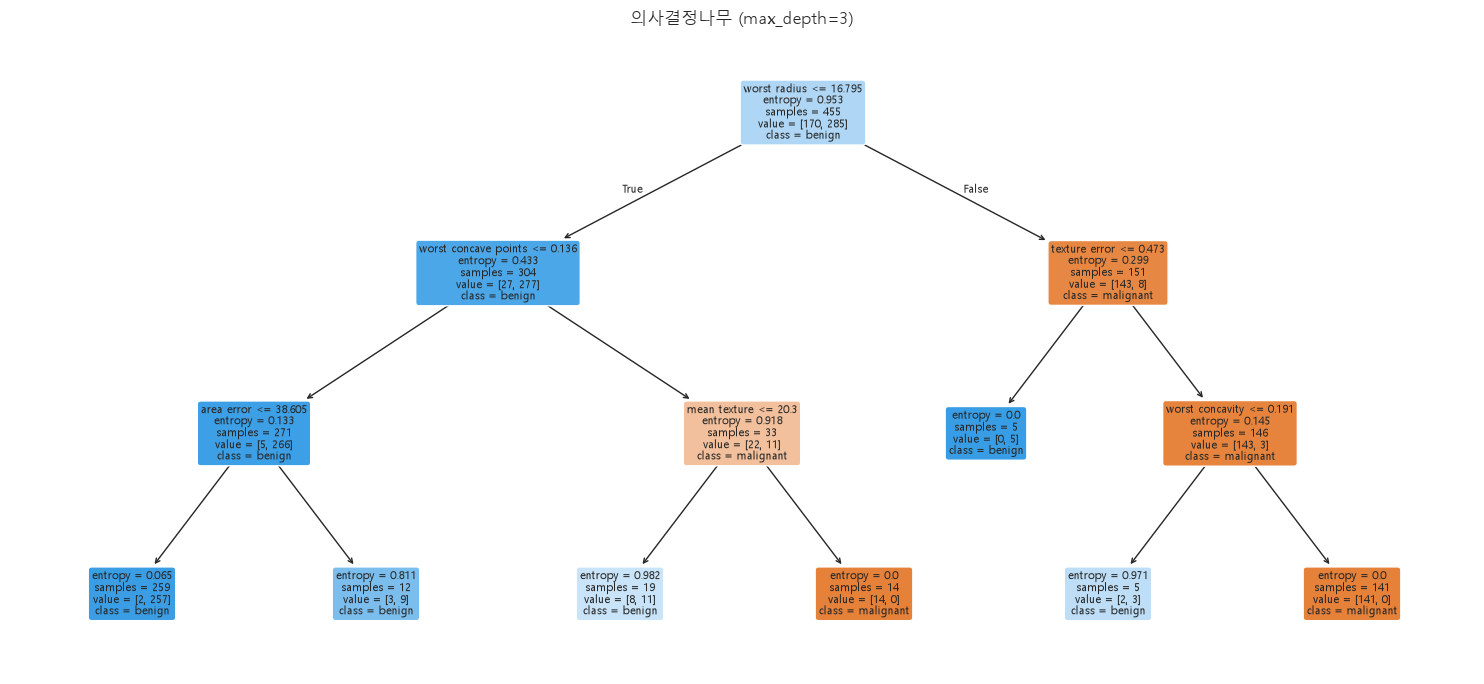

In [6]:
# [C4] ◀ Part 1 · 📊 데이터로 확인해 봅시다 — 트리를 학습하고 그려보기
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=3,criterion="entropy", random_state=RANDOM_STATE)
entropy_score = tree.fit(Xc_tr, yc_tr)
print(f"테스트 정확도 = {entropy_score.score(Xc_te, yc_te):.3f}")
print(f"테스트 정확도 = {gini_score.score(Xc_te, yc_te):.3f}")
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(tree, feature_names=Xc.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title("의사결정나무 (max_depth=3)")
plt.tight_layout(); plt.show()

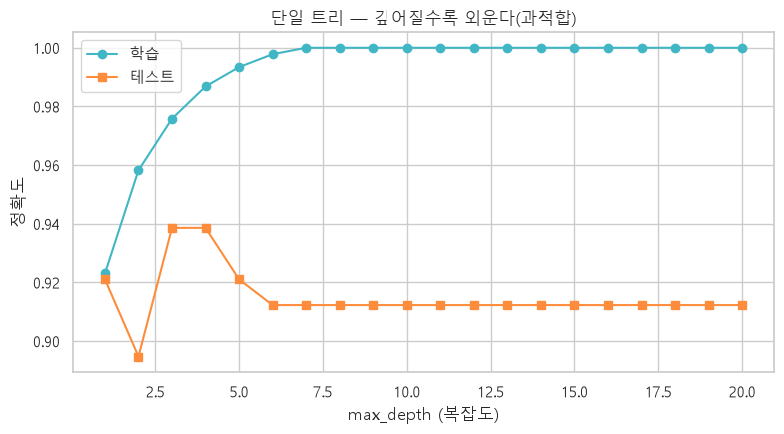

학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ 3


In [7]:
# ─────────────────────────────────────────────
# [C7] ◀ Part 2 · 📊 데이터로 확인해 봅시다 — 깊이를 키우면 무엇이 벌어지나 깊이를 키울수록 학습↑·테스트는 정체 → 과적합
# ─────────────────────────────────────────────
depths = range(1, 21)
tr, te = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    tr.append(m.score(Xc_tr, yc_tr)); te.append(m.score(Xc_te, yc_te))

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
plt.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("단일 트리 — 깊어질수록 외운다(과적합)")
plt.legend(); plt.tight_layout(); plt.show()

best = list(depths)[int(np.argmax(te))]
print(f"학습은 곧 1.0으로 수렴하지만 테스트는 정체합니다. 최적 깊이 ≈ {best}")

[min_samples_leaf=1] 최적 깊이 ≈ 3, 그때 테스트 정확도 = 0.939
[min_samples_leaf=5] 최적 깊이 ≈ 3, 그때 테스트 정확도 = 0.939
[min_samples_leaf=20] 최적 깊이 ≈ 1, 그때 테스트 정확도 = 0.921


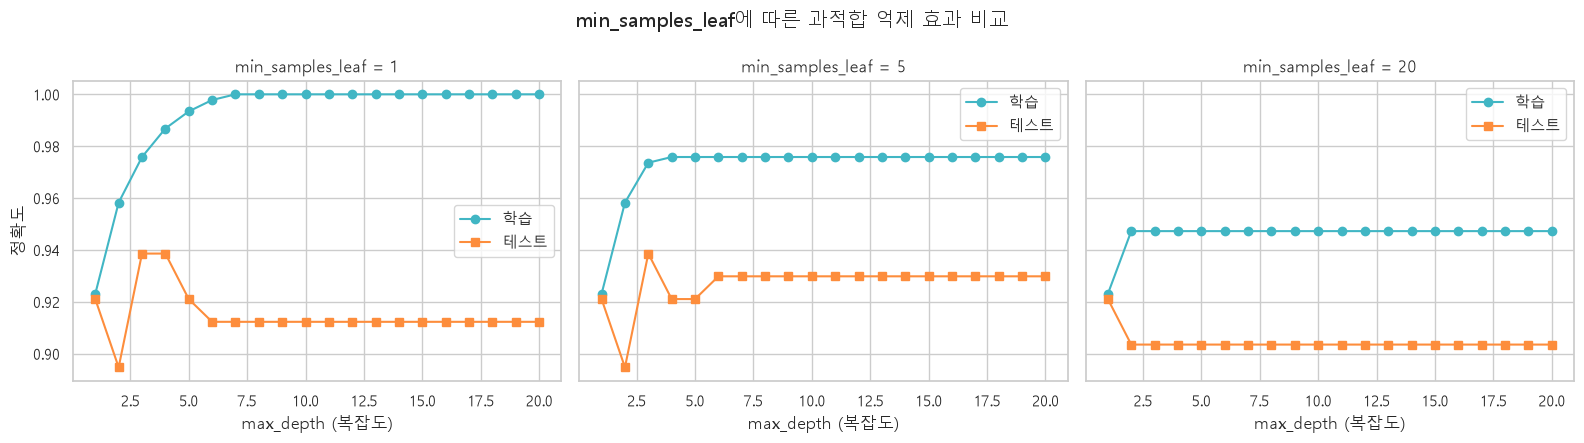

In [8]:
min_samples_leaf_values = [1, 5, 20]
depths = range(1, 21)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, msl in zip(axes, min_samples_leaf_values):
    tr, te = [], []
    for d in depths:
        m = DecisionTreeClassifier(
            max_depth=d,                 # 빠져있던 부분 — 깊이 제한 적용
            min_samples_leaf=msl,
            random_state=RANDOM_STATE
        ).fit(Xc_tr, yc_tr)
        tr.append(m.score(Xc_tr, yc_tr))
        te.append(m.score(Xc_te, yc_te))

    ax.plot(list(depths), tr, "o-", label="학습", color="#41b6c4")
    ax.plot(list(depths), te, "s-", label="테스트", color="#fd8d3c")
    ax.set_xlabel("max_depth (복잡도)")
    ax.set_title(f"min_samples_leaf = {msl}")
    ax.legend()

    best = list(depths)[int(np.argmax(te))]
    print(f"[min_samples_leaf={msl}] 최적 깊이 ≈ {best}, 그때 테스트 정확도 = {max(te):.3f}")

axes[0].set_ylabel("정확도")
plt.suptitle("min_samples_leaf에 따른 과적합 억제 효과 비교")
plt.tight_layout()
plt.show()

In [9]:
# [C9] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트 부트스트랩 한 번 — 중복과 누락 관찰
import numpy as np
np.random.seed(1)
original = np.arange(10)
boot = np.random.choice(original, size=10, replace=True)  # 복원추출
print("원본     :", original)
print("부트스트랩:", np.sort(boot))
print("뽑힌 고유값 개수:", len(set(boot)), "/ 10")
print(f"이론상 평균 포함 비율 ≈ {1-(1-1/len(original))**len(original):.0%}")

원본     : [0 1 2 3 4 5 6 7 8 9]
부트스트랩: [0 0 1 5 5 6 7 8 9 9]
뽑힌 고유값 개수: 7 / 10
이론상 평균 포함 비율 ≈ 65%


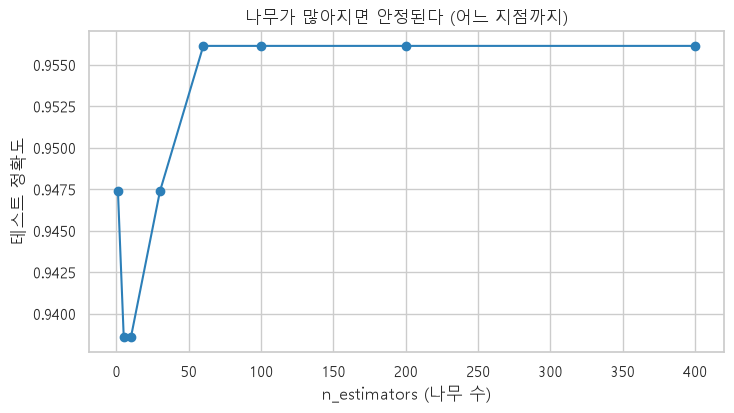

→ 나무가 적을 땐 출렁이다가, 늘릴수록 성능이 안정됩니다.


In [10]:
# ─────────────────────────────────────────────
# [C11] ◀ Part 3 · 📊 데이터로 확인해 봅시다 — 부트스트랩과 랜덤포레스트 나무 수(n_estimators)에 따른 테스트 정확도
# ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
ns = [1, 5, 10, 30, 60, 100, 200, 400]
scores = [RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
          .fit(Xc_tr, yc_tr).score(Xc_te, yc_te) for n in ns]

plt.figure(figsize=(7.5, 4.3))
plt.plot(ns, scores, "o-", color="#2c7fb8")
plt.xlabel("n_estimators (나무 수)"); plt.ylabel("테스트 정확도")
plt.title("나무가 많아지면 안정된다 (어느 지점까지)")
plt.tight_layout(); plt.show()
print("→ 나무가 적을 땐 출렁이다가, 늘릴수록 성능이 안정됩니다.")

In [11]:
# ─────────────────────────────────────────────
# [C13] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 AdaBoost — Stump를 순차로 쌓기
# ─────────────────────────────────────────────
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
print(f"AdaBoost 테스트 정확도 = {ada.score(Xc_te, yc_te):.3f}")

AdaBoost 테스트 정확도 = 0.965


In [12]:
# ─────────────────────────────────────────────
# [C14] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 Gradient Boosting — 잔차를 순차로 보정
# ─────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=3, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
print(f"Gradient Boosting 테스트 정확도 = {gbm.score(Xc_te, yc_te):.3f}")

Gradient Boosting 테스트 정확도 = 0.956


In [13]:
!pip install xgboost -q

In [14]:
# ─────────────────────────────────────────────
# [C15] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 XGBoost — 정규화된 부스팅
# ─────────────────────────────────────────────
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                    reg_lambda=1.0, random_state=RANDOM_STATE, eval_metric="logloss")
xgb_clf.fit(Xc_tr, yc_tr)
print(f"XGBoost 테스트 정확도 = {xgb_clf.score(Xc_te, yc_te):.3f}")

XGBoost 테스트 정확도 = 0.947


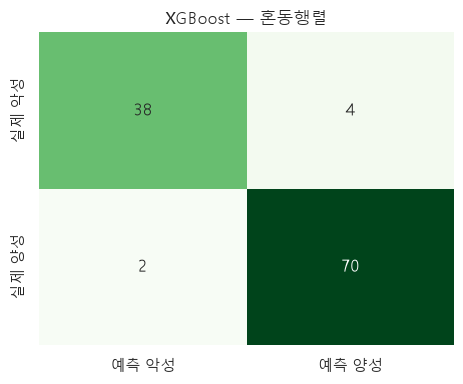

대각선이 정답. 이후 이 표로 정밀도·재현율을 계산합니다.


In [15]:
# [C16] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 XGBoost 혼동행렬 — 무엇을 맞히고 틀렸나
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(yc_te, xgb_clf.predict(Xc_te))
fig, ax = plt.subplots(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["예측 악성", "예측 양성"], yticklabels=["실제 악성", "실제 양성"], ax=ax)
ax.set_title("XGBoost — 혼동행렬"); plt.tight_layout(); plt.show()
print("대각선이 정답. 이후 이 표로 정밀도·재현율을 계산합니다.")

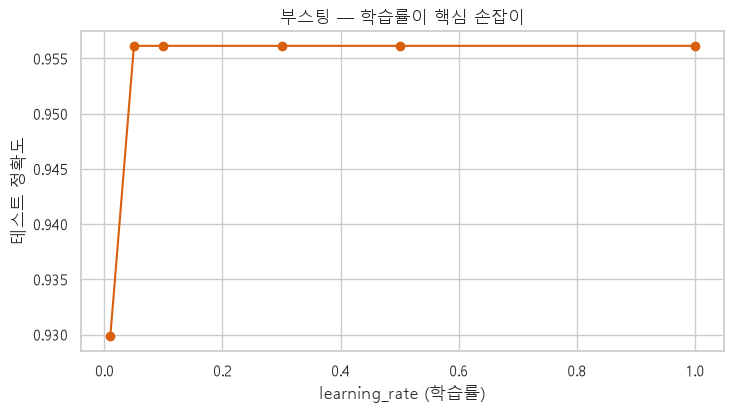

→ 너무 크면 불안정·과적합, 너무 작으면 더 많은 트리가 필요합니다(트레이드오프).


In [16]:
# ─────────────────────────────────────────────
# [C17] ◀ Part 4 · 📊 데이터로 확인해 봅시다 — 부스팅 3종을 차례로 학습률(learning_rate)이 부스팅에 미치는 영향
# ─────────────────────────────────────────────
lrs = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
acc_lr = [GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=3,
          random_state=RANDOM_STATE).fit(Xc_tr, yc_tr).score(Xc_te, yc_te) for lr in lrs]
plt.figure(figsize=(7.5, 4.3))
plt.plot(lrs, acc_lr, "o-", color="#d95f0e")
plt.xlabel("learning_rate (학습률)"); plt.ylabel("테스트 정확도")
plt.title("부스팅 — 학습률이 핵심 손잡이")
plt.tight_layout(); plt.show()
print("→ 너무 크면 불안정·과적합, 너무 작으면 더 많은 트리가 필요합니다(트레이드오프).")

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

single = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
single.fit(Xc_tr, yc_tr)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(Xc_tr, yc_tr)

ada = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
ada.fit(Xc_tr, yc_tr)

gbm = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE)
gbm.fit(Xc_tr, yc_tr)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

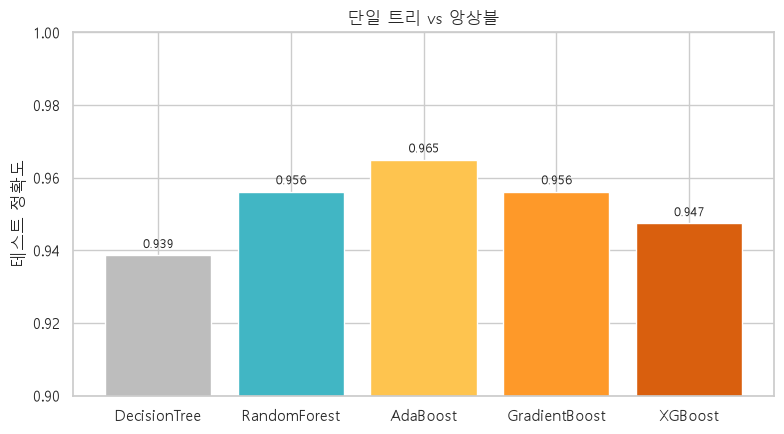

→ 앙상블(특히 부스팅)이 단일 트리보다 대체로 높고 안정적입니다.


In [22]:
# ─────────────────────────────────────────────
# [C19] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 모델별 테스트 정확도 비교
# ─────────────────────────────────────────────
names = ["DecisionTree", "RandomForest", "AdaBoost", "GradientBoost", "XGBoost"]
models = [single, rf, ada, gbm, xgb_clf]
accs = [m.score(Xc_te, yc_te) for m in models]

plt.figure(figsize=(8, 4.5))
bars = plt.bar(names, accs, color=["#bdbdbd", "#41b6c4", "#fec44f", "#fe9929", "#d95f0e"])
plt.ylim(0.9, 1.0); plt.ylabel("테스트 정확도")
plt.title("단일 트리 vs 앙상블")
for b, a in zip(bars, accs):
    plt.text(b.get_x()+b.get_width()/2, a+0.002, f"{a:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("→ 앙상블(특히 부스팅)이 단일 트리보다 대체로 높고 안정적입니다.")

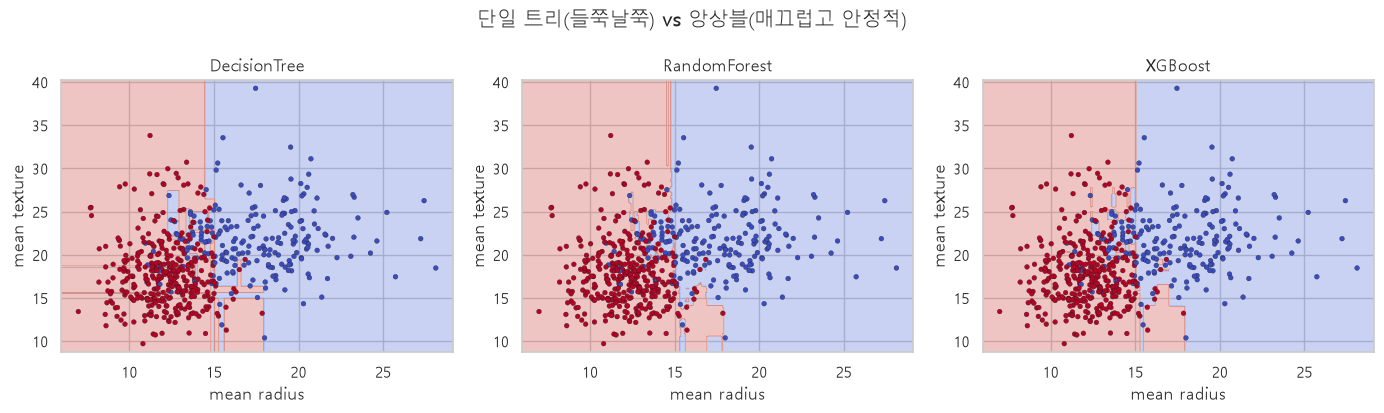

In [23]:
# ─────────────────────────────────────────────
# [C20] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 결정경계 비교 — Tree / RandomForest / XGBoost
# ─────────────────────────────────────────────
import numpy as np
feats = ["mean radius", "mean texture"]
X2 = Xc[feats].values
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 300),
                     np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

models2 = [("DecisionTree", DecisionTreeClassifier(max_depth=None, random_state=42)),
           ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
           ("XGBoost", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4,
                                     random_state=42, eval_metric="logloss"))]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, m) in zip(axes, models2):
    m.fit(X2, yc)
    zz = m.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2[:,0], X2[:,1], c=yc, cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(name); ax.set_xlabel(feats[0]); ax.set_ylabel(feats[1])
plt.suptitle("단일 트리(들쭉날쭉) vs 앙상블(매끄럽고 안정적)")
plt.tight_layout(); plt.show()

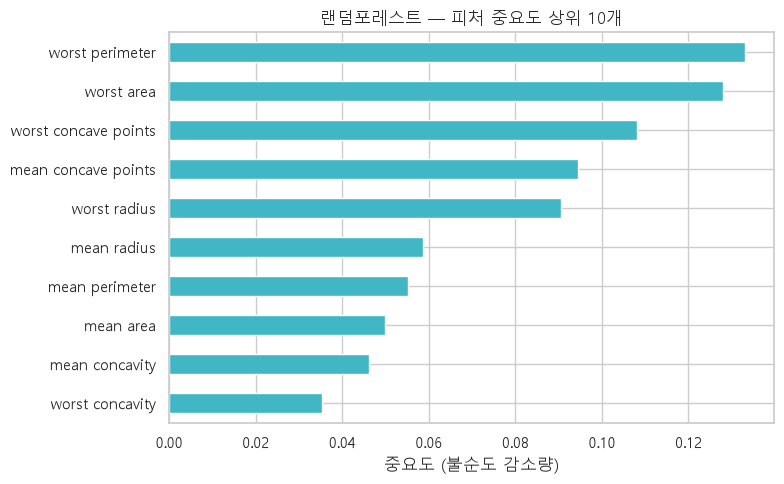

가장 중요한 피처 Top 3:
worst perimeter         0.133100
worst area              0.128052
worst concave points    0.108107
dtype: float64


In [24]:
# ─────────────────────────────────────────────
# [C21] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 피처 중요도 — 어떤 피처가 예측을 이끄는가 (랜덤포레스트)
# ─────────────────────────────────────────────
imp = pd.Series(rf.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
imp[::-1].plot(kind="barh", color="#41b6c4")
plt.title("랜덤포레스트 — 피처 중요도 상위 10개")
plt.xlabel("중요도 (불순도 감소량)")
plt.tight_layout(); plt.show()
print("가장 중요한 피처 Top 3:")
print(imp.head(3))

In [25]:
# ─────────────────────────────────────────────
# [C22] ◀ Part 5 · 📊 데이터로 확인해 봅시다 — 성능과 중요도를 한자리에 순열 중요도 — 피처를 섞으면 성능이 얼마나 떨어지나
# ─────────────────────────────────────────────
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, Xc_te, yc_te, n_repeats=10, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=Xc.columns).sort_values(ascending=False).head(5)
print("순열 중요도 Top 5 (섞었을 때 정확도 하락폭):")
print(perm_imp.round(4))
print("\n→ 불순도 기반과 순열 기반의 순위를 비교해 보세요. 대체로 비슷하지만 다를 수 있습니다.")

순열 중요도 Top 5 (섞었을 때 정확도 하락폭):
mean area              0.0088
compactness error      0.0088
worst perimeter        0.0088
worst area             0.0079
mean concave points    0.0079
dtype: float64

→ 불순도 기반과 순열 기반의 순위를 비교해 보세요. 대체로 비슷하지만 다를 수 있습니다.
